<a href="https://colab.research.google.com/github/FaizunKarim/DTS-Data-Scientist-Supervisor/blob/main/California%20Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# Loading the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [45]:
print('--- Data Structure ---')
display(df.info())

print('\n--- Missing Values Analysis ---')
missing_data = df.isnull().sum()
if missing_data.sum() == 0:
    print('Dataset is clean: No NaN values found.')
else:
    print(missing_data[missing_data > 0])

print('\n--- Detailed Descriptive Statistics ---')
display(df.describe().T)

--- Data Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


None


--- Missing Values Analysis ---
Dataset is clean: No NaN values found.

--- Detailed Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


--- Outlier Analysis Based on IQR ---
AveRooms    :   511 outliers (2.48%)
AveBedrms   :  1424 outliers (6.90%)
AveOccup    :   711 outliers (3.44%)
MedInc      :   681 outliers (3.30%)


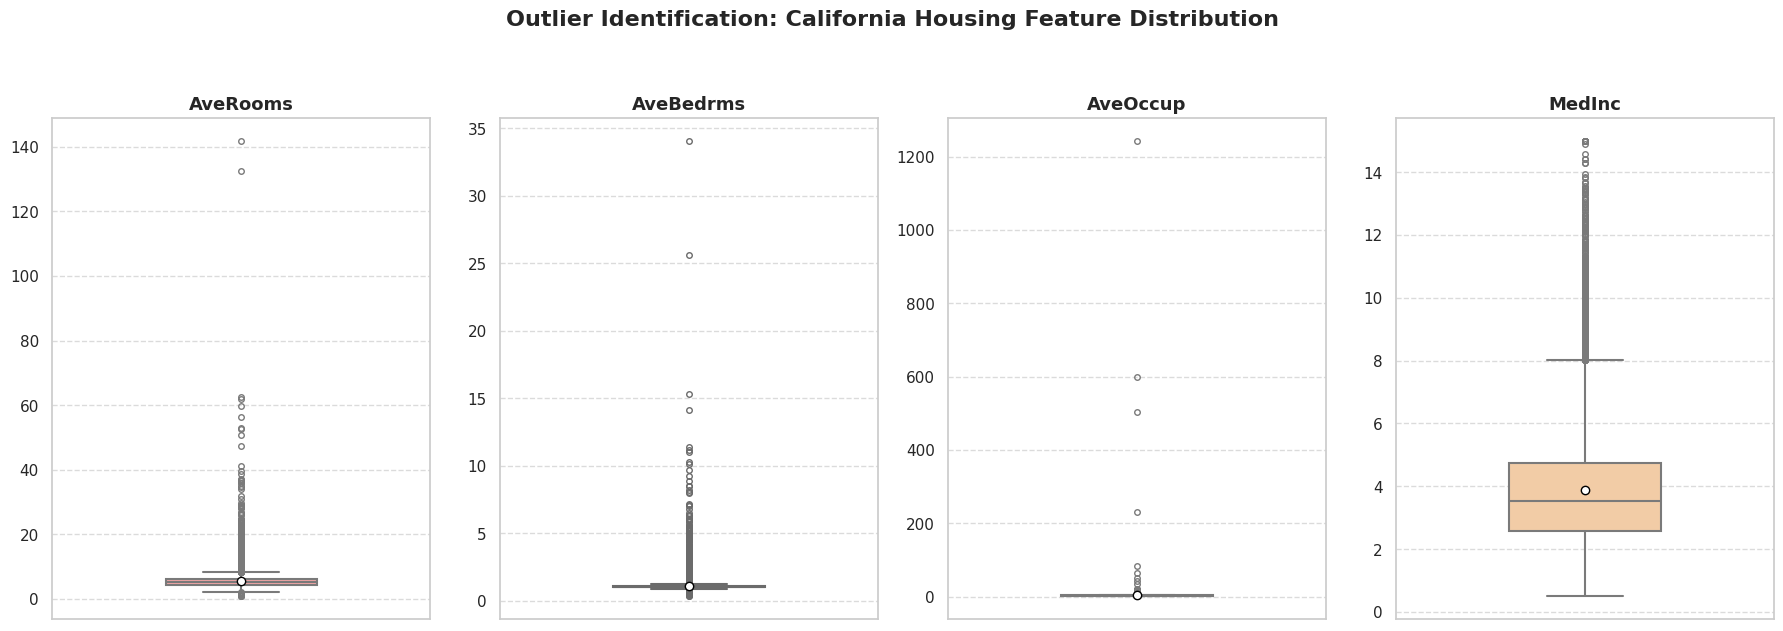

In [46]:
print('--- Outlier Analysis Based on IQR ---')
cols_to_check = ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    percentage = (len(outliers) / len(df)) * 100
    print(f'{col:12}: {len(outliers):>5} outliers ({percentage:.2f}%)')

# Enhanced boxplot visualization
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

for i, col in enumerate(cols_to_check):
    sns.boxplot(y=df[col], ax=axes[i], color=colors[i],
                width=0.4, fliersize=4, linewidth=1.5,
                showmeans=True, meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black'})
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Outlier Identification: California Housing Feature Distribution', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

--- Correlation Matrix (Pearson) ---


,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


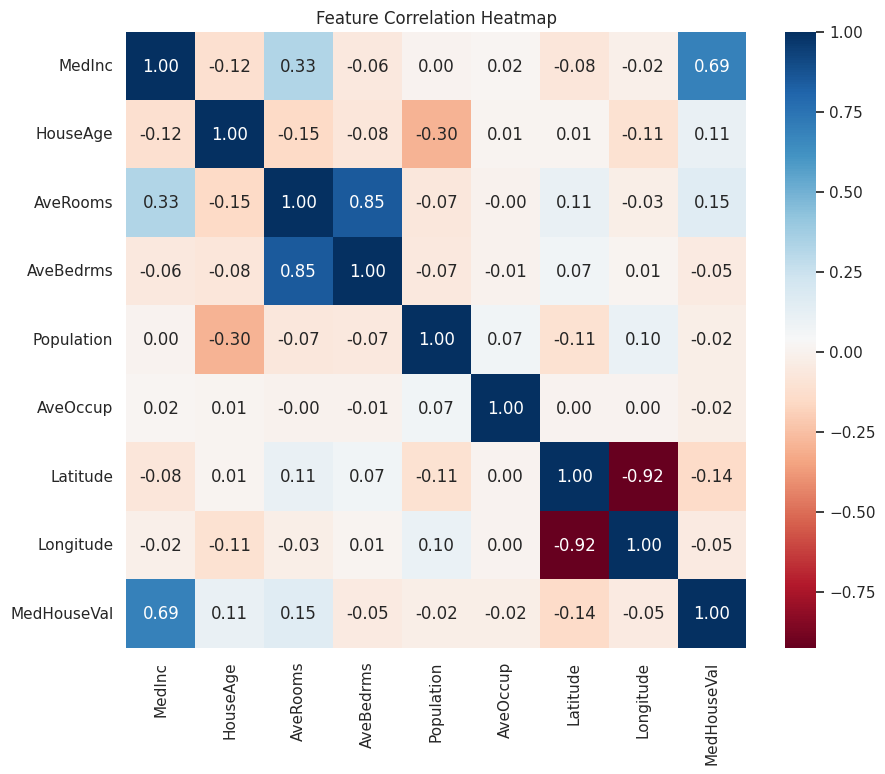


Analysis: MedInc has the strongest positive correlation with the target (MedHouseVal).


In [47]:
print('--- Correlation Matrix (Pearson) ---')
corr_matrix = df.corr()
display(corr_matrix['MedHouseVal'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

print('\nAnalysis: MedInc has the strongest positive correlation with the target (MedHouseVal).')

--- Skewness Analysis ---
AveOccup       97.639561
AveBedrms      31.316956
AveRooms       20.697869
Population      4.935858
MedInc          1.646657
MedHouseVal     0.977763
Latitude        0.465953
HouseAge        0.060331
Longitude      -0.297801
dtype: float64


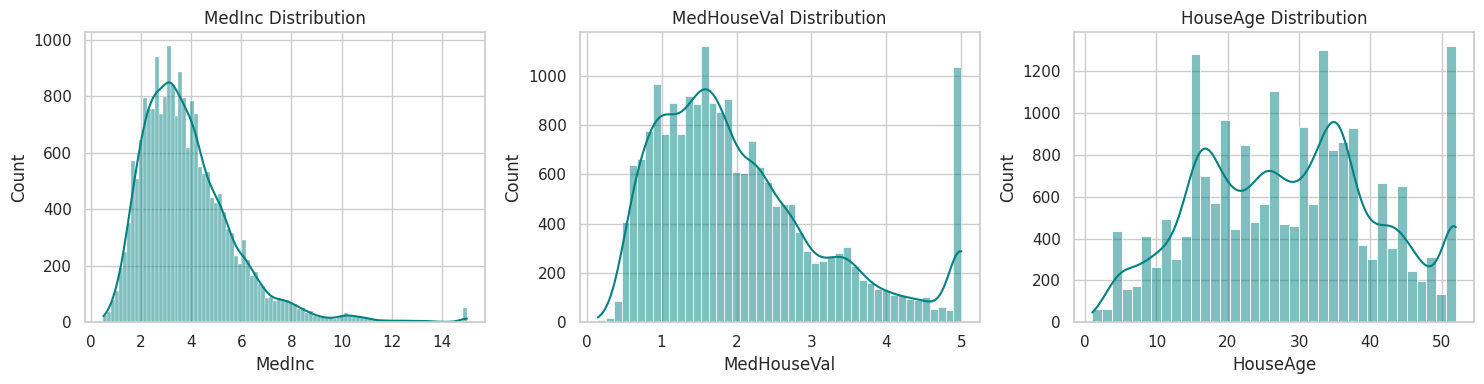


Note: High skewness in AveOccup and AveRooms confirms the need for outlier cleaning.


In [48]:
print('--- Skewness Analysis ---')
skew_values = df.skew().sort_values(ascending=False)
print(skew_values)

plt.figure(figsize=(15, 4))
for i, col in enumerate(['MedInc', 'MedHouseVal', 'HouseAge'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

print('\nNote: High skewness in AveOccup and AveRooms confirms the need for outlier cleaning.')

In [55]:
from sklearn.preprocessing import StandardScaler

# Feature engineering: calculating Bedrooms per Room
df_cleaned['BedroomsPerRoom'] = df_cleaned['AveBedrms'] / df_cleaned['AveRooms']

# List of features to scale
features_to_scale = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'BedroomsPerRoom']

# Initialize scaler and transform data
scaler = StandardScaler()
df_transformed = df_cleaned.copy()
df_transformed[features_to_scale] = scaler.fit_transform(df_cleaned[features_to_scale])

print('--- Transformed DataFrame Head ---')
display(df_transformed.head())

print('\n--- Transformed Descriptive Statistics ---')
display(df_transformed[features_to_scale].describe().loc[['mean', 'std', 'min', 'max']])

--- Transformed DataFrame Head ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,BedroomsPerRoom
0,2.469497,0.967120,1.552958,-0.365717,-1.048740,-0.481017,1.066368,-1.318799,4.526,-1.212859
1,2.456219,-0.634003,0.889441,-1.153479,0.877563,-1.192988,1.056919,-1.313776,3.585,-1.037727
2,1.873752,1.847737,2.712803,0.387272,-0.887520,-0.086938,1.052194,-1.323823,3.521,-1.537696
3,0.973105,1.847737,0.515175,0.381402,-0.830073,-0.493173,1.052194,-1.328846,3.413,-0.492457
4,-0.029419,1.847737,0.928324,0.503091,-0.823588,-1.078576,1.052194,-1.328846,3.422,-0.727645



--- Transformed Descriptive Statistics ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,BedroomsPerRoom
mean,3.088477e-17,9.265431e-17,-1.729547e-16,-6.582317e-16,1.853086e-17,-5.188641e-16,-2.075457e-15,-7.461760e-15,3.026707e-16
std,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00
min,-1.876240e+00,-2.235125e+00,-2.851034e+00,-2.759486e+00,-1.342457e+00,-2.708179e+00,-1.456614e+00,-2.383740e+00,-1.970131e+00
max,6.193546e+00,1.847737e+00,2.874329e+00,2.906621e+00,1.376035e+01,2.722024e+00,2.989316e+00,2.529054e+00,6.744283e+00


In [56]:
# Categorizing house values into Low, Medium, and High labels
def label_house_value(val):
    if val < 1.5:
        return 'Low'
    elif val <= 3.0:
        return 'Medium'
    else:
        return 'High'

df_transformed['ValueCategory'] = df_transformed['MedHouseVal'].apply(label_house_value)

print('--- Value Category Distribution ---')
print(df_transformed['ValueCategory'].value_counts())

print('\n--- Sample with Labels ---')
display(df_transformed[['MedHouseVal', 'ValueCategory']].head())

--- Value Category Distribution ---
ValueCategory
Medium    8576
Low       6363
High      3466
Name: count, dtype: int64

--- Sample with Labels ---


,MedHouseVal,ValueCategory
0,4.526,High
1,3.585,High
2,3.521,High
3,3.413,High
4,3.422,High


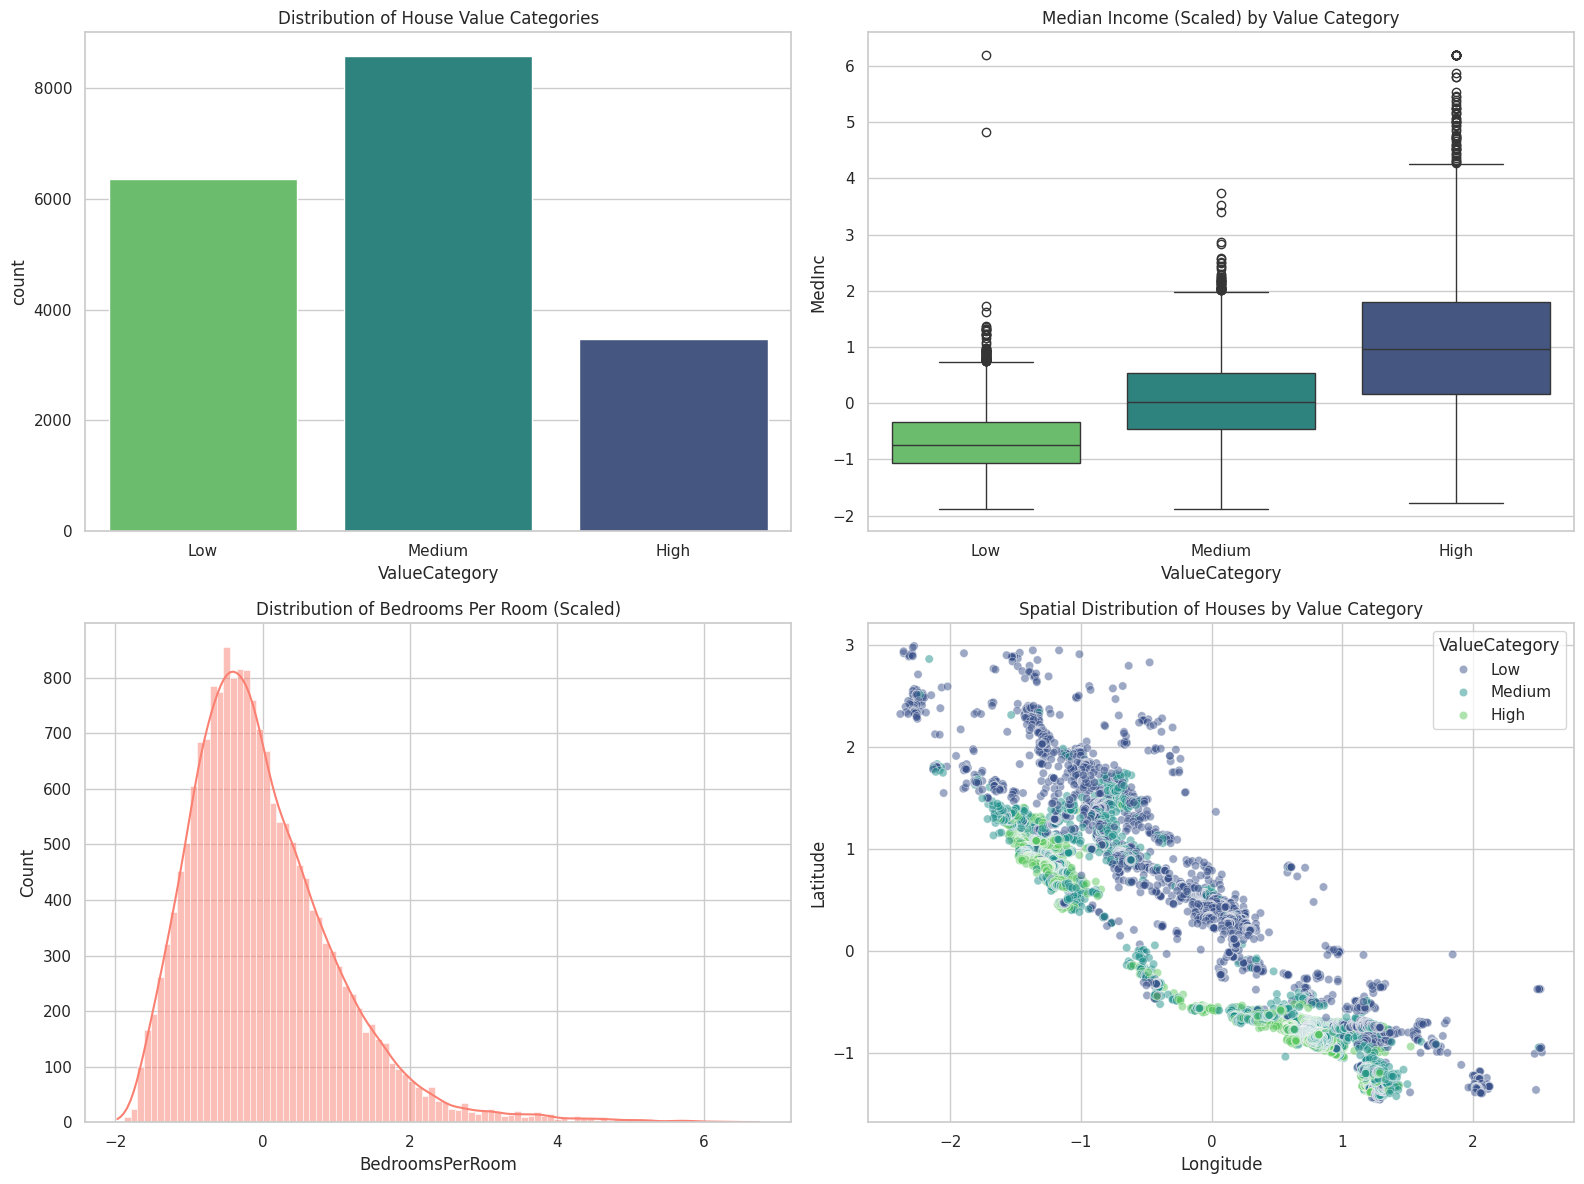

--- Descriptive Statistics for Features by Value Category ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,BedroomsPerRoom
ValueCategory,,,,,,,,,
High,1.094715,0.242665,0.627323,-0.079662,-0.129030,-0.526982,-0.091568,-0.137389,-0.454374
Low,-0.669317,-0.073258,-0.258293,0.157043,-0.032807,0.230559,0.283467,-0.024666,0.198094
Medium,0.054172,-0.043720,-0.061892,-0.084324,0.076489,0.041916,-0.173312,0.073827,0.036659


In [57]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution plot
sns.countplot(x='ValueCategory', hue='ValueCategory', data=df_transformed, ax=axes[0, 0], order=['Low', 'Medium', 'High'], palette='viridis', legend=False)
axes[0, 0].set_title('Distribution of House Value Categories')

# Relationship between income and category
sns.boxplot(x='ValueCategory', y='MedInc', hue='ValueCategory', data=df_transformed, ax=axes[0, 1], order=['Low', 'Medium', 'High'], palette='viridis', legend=False)
axes[0, 1].set_title('Median Income (Scaled) by Value Category')

# Engineered feature distribution
sns.histplot(df_transformed['BedroomsPerRoom'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution of Bedrooms Per Room (Scaled)')

# Geographical distribution
sns.scatterplot(x='Longitude', y='Latitude', hue='ValueCategory', data=df_transformed, ax=axes[1, 1], palette='viridis', alpha=0.5, hue_order=['Low', 'Medium', 'High'])
axes[1, 1].set_title('Spatial Distribution of Houses by Value Category')

plt.tight_layout()
plt.show()

print('--- Descriptive Statistics for Features by Value Category ---')
display(df_transformed.groupby('ValueCategory')[features_to_scale].mean())

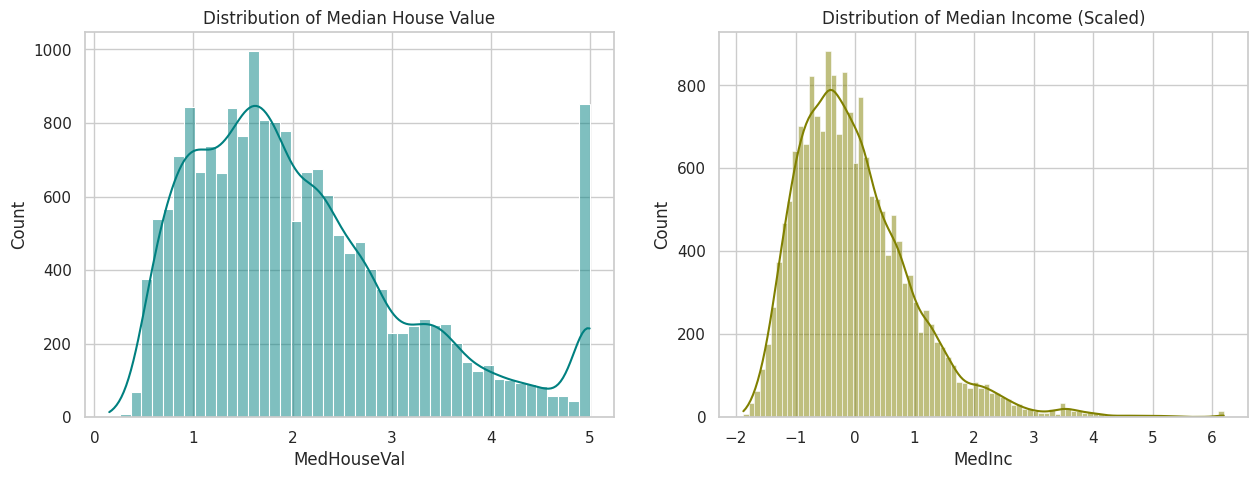

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_transformed['MedHouseVal'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Median House Value')

sns.histplot(df_transformed['MedInc'], kde=True, ax=axes[1], color='olive')
axes[1].set_title('Distribution of Median Income (Scaled)')

plt.show()

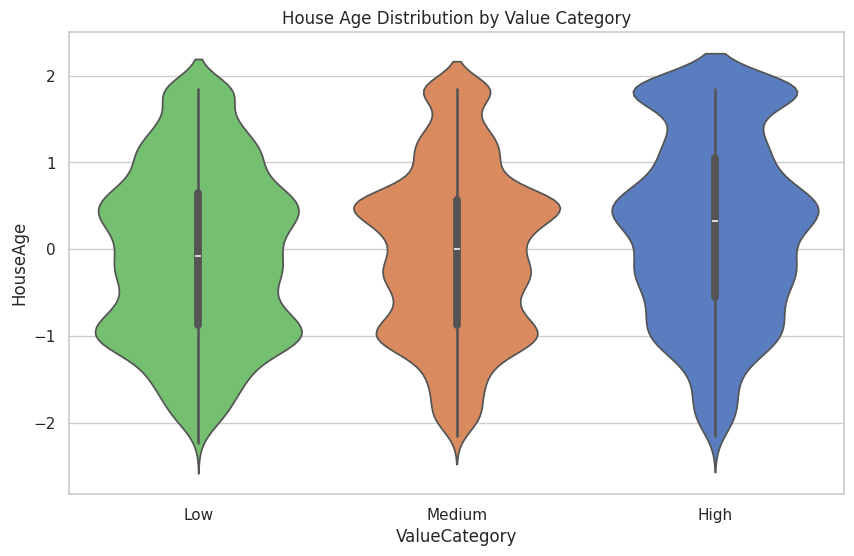

In [53]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='ValueCategory', y='HouseAge', hue='ValueCategory', data=df_transformed, palette='muted', order=['Low', 'Medium', 'High'], legend=False)
plt.title('House Age Distribution by Value Category')
plt.show()

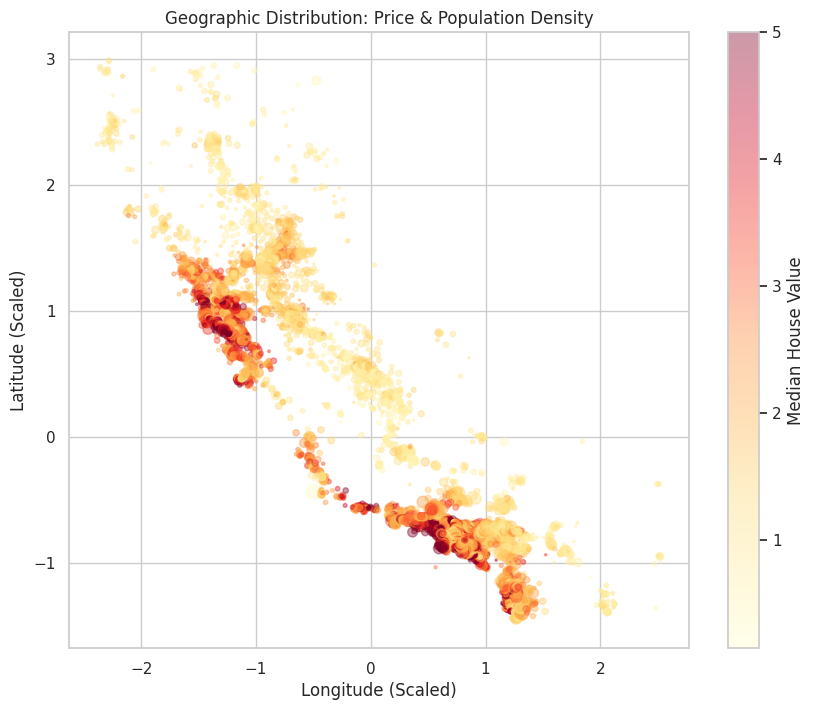

In [54]:
plt.figure(figsize=(10, 8))
# Clip population to ensure no negative sizes for the scatter plot
sizes = (df_transformed['Population'] - df_transformed['Population'].min() + 0.1) * 10
plt.scatter(df_transformed['Longitude'], df_transformed['Latitude'],
            c=df_transformed['MedHouseVal'], cmap='YlOrRd', alpha=0.4, s=sizes)
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude (Scaled)')
plt.ylabel('Latitude (Scaled)')
plt.title('Geographic Distribution: Price & Population Density')
plt.show()